# Hari 5-7 — EDA Mendalam & Konsolidasi Minggu 1 (Versi Latihan)

**Recap keputusan dari Hari 4:**
- Periode sebelum vaksinasi (sebelum Jan 2021): **diisi angka 0**
- Fitur vaksinasi yang dipakai: **persentase populasi tervaksin** (bukan angka kumulatif mentah)
- Ada catatan **"lonjakan aneh"** di grafik yang perlu diselidiki lebih lanjut

**Cara pakai notebook ini:** beberapa cell sudah berisi kode lengkap (setup & satu library baru), tapi sebagian besar cell **sengaja dikosongkan** — hanya berisi komentar `#` yang memandu langkah demi langkah. Tulis kodenya sendiri sesuai komentar, lalu jalankan. Ini melatih tanganmu, bukan cuma mata.

Tiga bagian: **Hari 5** (statistik deskriptif + terapkan keputusan Hari 4), **Hari 6** (dekomposisi time-series + deteksi outlier), **Hari 7** (konsolidasi Minggu 1).

---
# BAGIAN A — Hari 5: Statistik Deskriptif & Menerapkan Keputusan

In [1]:
# Cell ini sudah lengkap (boilerplate setup, sama seperti Hari 3-4)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

vaksin = pd.read_csv("vaksinasi.csv")
kasus = pd.read_csv("harian.csv")

vaksin["Date"] = pd.to_datetime(vaksin["key_as_string"], utc=True)
kasus["Date"] = pd.to_datetime(kasus["key_as_string"], utc=True)

vaksin = vaksin.sort_values("Date").set_index("Date")
kasus = kasus.sort_values("Date").set_index("Date")

kasus_mingguan = kasus["jumlah_positif"].resample("W").sum().rename("kasus_baru_mingguan")
vaksin_mingguan = vaksin["jumlah_jumlah_vaksinasi_1_kum"].resample("W").last().rename("vaksin_dosis1_kumulatif")

gabungan = pd.concat([kasus_mingguan, vaksin_mingguan], axis=1)
print(f"Data gabungan awal: {gabungan.shape[0]} minggu")

Data gabungan awal: 147 minggu


## Menerapkan Keputusan #1: Isi Periode Sebelum Vaksinasi dengan 0

In [3]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Kolom "vaksin_dosis1_kumulatif" di dataframe `gabungan` masih punya NaN untuk minggu-minggu sebelum vaksinasi dimulai.
# 2. Gunakan method .fillna() pada kolom tersebut untuk mengisi nilai kosong dengan 0.
#    Ingat: harus di-assign balik ke gabungan["vaksin_dosis1_kumulatif"], jangan lupa method .fillna() 
#    tidak mengubah data asli kecuali di-assign ulang.
# 3. Setelah itu, cetak (print) gabungan.isnull().sum() untuk memastikan kolom ini sudah 0 missing values.
# Tulis kode kamu di bawah ini:
gabungan['vaksin_dosis1_kumulatif'] = gabungan['vaksin_dosis1_kumulatif'].fillna(0)
print("Missing values setelah fillna (0)")
print (gabungan.isnull().sum())


Missing values setelah fillna (0)
kasus_baru_mingguan        0
vaksin_dosis1_kumulatif    0
dtype: int64


## Menerapkan Keputusan #2: Ubah ke Persentase Populasi Tervaksin

Kita pakai angka populasi Indonesia dari sensus 2020 (~270,2 juta) sebagai penyebut. **Catatan penting:** ini angka statis (tidak memperhitungkan pertumbuhan penduduk tahun ke tahun) — cukup akurat untuk proyek belajar ini, tapi bukan angka resmi real-time.

In [5]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Buat variabel POPULASI_INDONESIA = 270_203_917 (boleh pakai underscore sebagai pemisah ribuan di Python, 
#    ini valid dan memudahkan baca angka besar)
# 2. Buat kolom baru "vaksin_persen" di gabungan, isinya: (kolom vaksin_dosis1_kumulatif dibagi POPULASI_INDONESIA) dikali 100
# 3. Setelah kolom persentase jadi, kolom "vaksin_dosis1_kumulatif" yang lama sudah tidak dipakai lagi — 
#    hapus dengan gabungan.drop(columns=[...]) dan assign balik ke gabungan (atau pakai parameter inplace=True)
# 4. Cetak gabungan[["kasus_baru_mingguan", "vaksin_persen"]].tail(10) untuk melihat hasil 10 baris terakhir
# Tulis kode kamu di bawah ini:
POPULASI_INDONESIA = 270_203_917
gabungan["vaksin_persen"] = (gabungan["vaksin_dosis1_kumulatif"] / POPULASI_INDONESIA) * 100
gabungan = gabungan.drop(columns=["vaksin_dosis1_kumulatif"])
print(gabungan[["kasus_baru_mingguan", "vaksin_persen"]].tail(10))

                           kasus_baru_mingguan  vaksin_persen
Date                                                         
2022-10-23 00:00:00+00:00                14093      75.902626
2022-10-30 00:00:00+00:00                19661      75.919834
2022-11-06 00:00:00+00:00                30670      75.938977
2022-11-13 00:00:00+00:00                40212      75.960700
2022-11-20 00:00:00+00:00                46863      75.984620
2022-11-27 00:00:00+00:00                41877      76.020068
2022-12-04 00:00:00+00:00                29959      75.398628
2022-12-11 00:00:00+00:00                18587      75.434557
2022-12-18 00:00:00+00:00                10807      75.464296
2022-12-25 00:00:00+00:00                 6527      75.489253


## Statistik Deskriptif Lengkap

In [6]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Cetak gabungan.describe() untuk statistik deskriptif standar (mean, std, min, max, quartile, dst)
# 2. Cetak skewness dari kolom "kasus_baru_mingguan" dengan method .skew()
# 3. Ingat dari materi hari ini: skewness > 1 berarti distribusi menceng kanan
#    (banyak minggu kasus rendah, sedikit minggu lonjakan tinggi) — ini WAJAR
#    untuk data pandemi, bukan tanda kesalahan data. Tulis satu baris komentar
#    di kode kamu yang menyimpulkan apakah data kamu menceng kanan atau tidak.
# Tulis kode kamu di bawah ini:
print(gabungan.describe())
print("\nSkewness (kemencengan distribusi): ")
print(gabungan["kasus_baru_mingguan"].skew())

       kasus_baru_mingguan  vaksin_persen
count           147.000000     147.000000
mean          45687.918367      32.487534
std           72398.029301      33.222648
min               6.000000       0.000000
25%            6958.500000       0.000000
50%           23648.000000      17.571236
75%           41175.500000      73.219747
max          389727.000000      76.020068

Skewness (kemencengan distribusi): 
2.9064372358558797


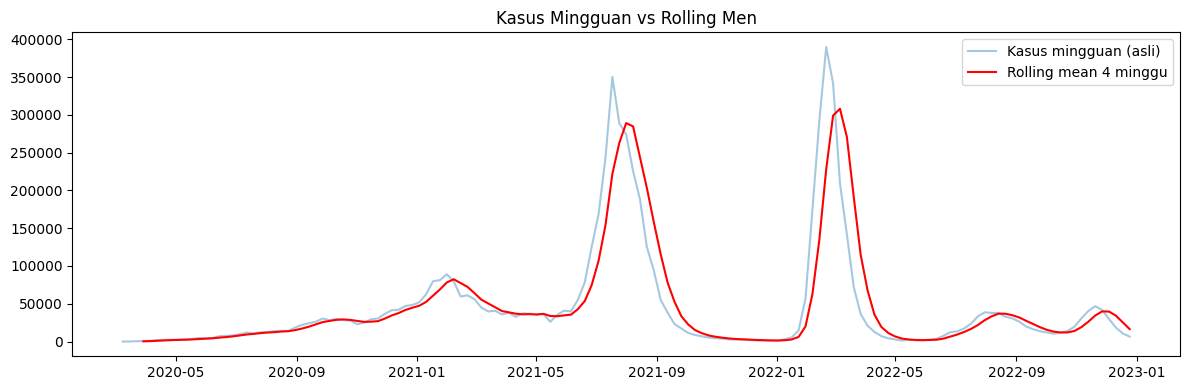

In [7]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Buat kolom baru "rolling_mean_4w" = rolling mean 4 minggu dari kolom "kasus_baru_mingguan" (gunakan .rolling(4).mean())
# 2. Buat kolom baru "rolling_std_4w" = rolling std 4 minggu dari kolom yang sama (gunakan .rolling(4).std())
# 3. Buat satu figure matplotlib (plt.figure(figsize=(12, 4)))
# 4. Plot kolom "kasus_baru_mingguan" asli dengan alpha=0.4 (transparan), beri label "Kasus mingguan (asli)"
# 5. Plot kolom "rolling_mean_4w" di atasnya dengan warna merah, beri label "Rolling mean 4 minggu"
# 6. Tambahkan plt.legend(), plt.title(...), plt.tight_layout(), plt.show()
# Tulis kode kamu di bawah ini:
gabungan["rolling_mean_4w"] = gabungan["kasus_baru_mingguan"].rolling(4).mean()
gabungan["rolling_std_4w"] = gabungan["kasus_baru_mingguan"].rolling(4).std()
plt.figure(figsize=(12, 4))
plt.plot(gabungan["kasus_baru_mingguan"], alpha=0.4, label="Kasus mingguan (asli)")
plt.plot(gabungan["rolling_mean_4w"], color="red", label="Rolling mean 4 minggu")
plt.legend()
plt.title("Kasus Mingguan vs Rolling Men")
plt.tight_layout()
plt.show()

In [12]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Buat kolom baru "growth_rate" = perubahan persentase minggu-ke-minggu
#    dari kolom "kasus_baru_mingguan", gunakan .pct_change() lalu kali 100
# 2. Cetak gabungan["growth_rate"].describe()
# 3. Hitung dan cetak berapa jumlah minggu dengan growth_rate > 100
#    (artinya kasus lebih dari dua kali lipat dibanding minggu sebelumnya)
#    Hint: gunakan boolean filtering lalu .sum() untuk menghitung True
# 4. Hitung dan cetak berapa jumlah minggu dengan growth_rate < -50
#    (artinya kasus turun lebih dari separuh dibanding minggu sebelumnya)
# Tulis kode kamu di bawah ini:
gabungan["growth_rate"] = gabungan["kasus_baru_mingguan"].pct_change() * 100
print(gabungan["growth_rate"].describe())
print(f"\nkasus lebih dari dua kali lipat dibanding minggu sebelumnya:  {(gabungan["growth_rate"] > 100).sum()}")
print(f"kasus turun lebih dari separuh dibanding minggu sebelumnya:  {(gabungan["growth_rate"] < -50).sum()}")

count     146.000000
mean       22.271279
std       152.129177
min       -51.868512
25%       -16.612670
50%         1.355098
75%        22.095612
max      1750.000000
Name: growth_rate, dtype: float64

kasus lebih dari dua kali lipat dibanding minggu sebelumnya:  7
kasus turun lebih dari separuh dibanding minggu sebelumnya:  1


---
# BAGIAN B — Hari 6: Dekomposisi Time-Series & Deteksi Outlier

Sekarang kita selidiki "lonjakan aneh" yang kamu catat di Hari 4, dengan cara yang lebih sistematis daripada sekadar melihat grafik.

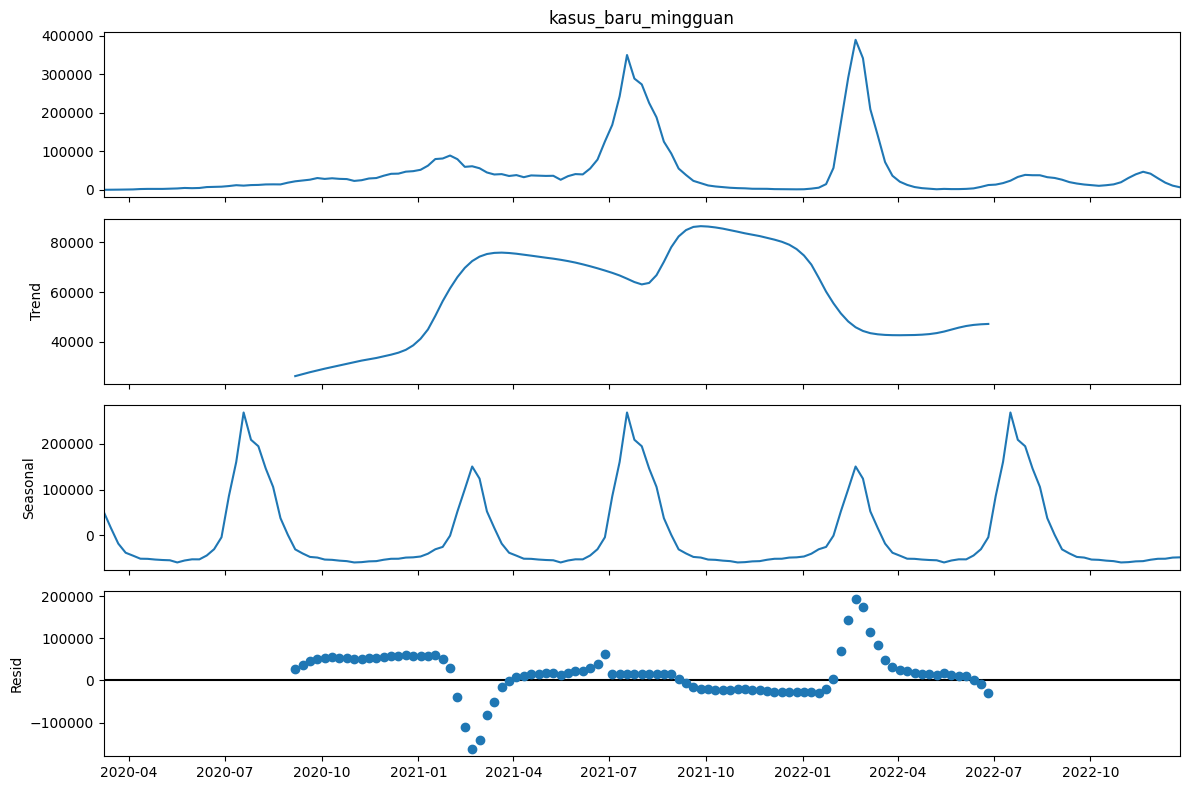

In [13]:
# Cell ini sudah lengkap — statsmodels adalah library baru, jadi contoh dulu
# sebelum kamu praktik sendiri di cell-cell berikutnya.
# statsmodels biasanya sudah terinstall di Colab. Jika belum, uncomment baris di bawah:
# !pip install statsmodels --quiet

from statsmodels.tsa.seasonal import seasonal_decompose

# Perlu data tanpa NaN. Interpolasi kecil untuk titik yang masih kosong (jika ada).
series = gabungan["kasus_baru_mingguan"].interpolate()

# period=52 karena data mingguan, pola tahunan = 52 minggu
decomposition = seasonal_decompose(series, model="additive", period=52)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

Perhatikan komponen **residual** (panel paling bawah) — ini adalah bagian data yang *tidak* dijelaskan oleh tren atau pola musiman. Titik-titik residual yang jauh dari nol itulah kandidat "lonjakan aneh". Kita deteksi secara sistematis di cell-cell berikut — kali ini kamu yang tulis kodenya.

In [15]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Ambil residual dari hasil decompose: decomposition.resid, lalu buang
#    baris NaN dengan .dropna(). Simpan ke variabel bernama `residual`.
# 2. Hitung Q1 (kuartil 25%) dan Q3 (kuartil 75%) dari `residual` dengan method .quantile(0.25) dan .quantile(0.75)
# 3. Hitung IQR = Q3 - Q1
# 4. Hitung batas_bawah = Q1 - 1.5 * IQR, dan batas_atas = Q3 + 1.5 * IQR (ini rumus standar deteksi outlier dengan metode IQR)
# 5. Filter `residual` untuk ambil nilai yang lebih kecil dari batas_bawah
#    ATAU lebih besar dari batas_atas — simpan ke variabel `outlier_weeks`
# 6. Cetak berapa banyak minggu yang terdeteksi, dan cetak isi outlier_weeks
# Tulis kode kamu di bawah ini:
residual = decomposition.resid.dropna()
Q1 = residual.quantile(0.25)
Q3 = residual.quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR
outlier_weeks = residual[(residual < batas_bawah) | (residual > batas_atas)]
print(f"Ditemukan {len(outlier_weeks)} minggu terindikasi outlier dari {len(residual)} minggu:")
print(outlier_weeks)

Ditemukan 4 minggu terindikasi outlier dari 95 minggu:
Date
2021-02-21 00:00:00+00:00   -161817.227163
2021-02-28 00:00:00+00:00   -142148.881010
2022-02-20 00:00:00+00:00    193419.051683
2022-02-27 00:00:00+00:00    173750.705529
Name: resid, dtype: float64


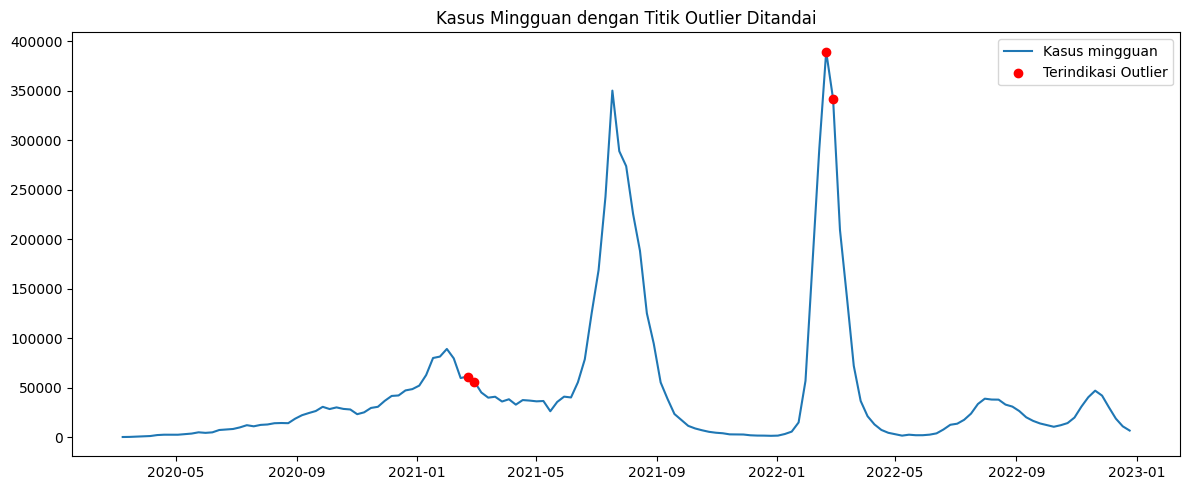

In [18]:
# LATIHAN — tulis kodenya sendiri sesuai panduan komentar di bawah:
# 1. Buat figure baru (plt.figure(figsize=(12, 5)))
# 2. Plot garis kasus_baru_mingguan seperti biasa, beri label "Kasus mingguan"
# 3. Tambahkan plt.scatter() di titik-titik yang index-nya ada di outlier_weeks.index
#    (ambil nilainya dari gabungan.loc[outlier_weeks.index, "kasus_baru_mingguan"]),
#    beri warna merah, zorder=5, dan label "Terindikasi outlier"
# 4. Tambahkan legend, title, tight_layout, show seperti biasa
# Tulis kode kamu di bawah ini:
plt.figure(figsize=(12, 5))
plt.plot(gabungan["kasus_baru_mingguan"], label="Kasus mingguan")
plt.scatter(outlier_weeks.index, gabungan.loc[outlier_weeks.index, "kasus_baru_mingguan"], color="red", zorder=5, label="Terindikasi Outlier")
plt.legend()
plt.title("Kasus Mingguan dengan Titik Outlier Ditandai")
plt.tight_layout()
plt.show()

**Penting:** tidak semua titik yang ditandai di sini otomatis "data salah". Di data pandemi, lonjakan/penurunan tajam sering kali **nyata** — misalnya akibat keterlambatan pelaporan yang menumpuk lalu dirilis sekaligus, hari libur nasional yang menghentikan sementara pelaporan, atau memang gelombang varian baru.

---
# BAGIAN C — Hari 7: Konsolidasi & Penutupan Minggu 1

## EDA Summary Report — Minggu 1

**Proyek:** Prediksi Tren Kasus COVID-19 Mingguan Indonesia (nasional, horizon 1 minggu)

**Business Understanding (Hari 1-2)**
- Business objective: bantu masyarakat umum memahami tren kasus naik/turun/stabil
- Baseline naive forecast sudah dihitung di Hari 2 sebagai pembanding model nanti

**Data Understanding (Hari 3-7)**
- Sumber data: covid19.go.id (kasus harian + vaksinasi harian, level nasional)
- Rentang data kasus: 2020-03-02 s/d 2022-12-25 (147 minggu)
- Rentang data vaksinasi: 2021-02-01 s/d 2022-12-25
- Distribusi kasus mingguan menceng kanan (skewed) — wajar untuk data pandemi
- Ditemukan pola musiman/gelombang saat dekomposisi time-series (lihat grafik Hari 6)
- Sejumlah minggu terindikasi outlier melalui analisis residual — dicatat untuk ditangani di Data Preparation

**Keputusan yang sudah diambil**
1. Data vaksinasi sebelum Jan 2021 diisi 0 (bukan dipotong)
2. Fitur vaksinasi final: persentase populasi tervaksin dosis-1 (bukan angka mentah)
3. Outlier residual sudah terdeteksi otomatis — cara penanganannya diputuskan di refleksi bawah

## Refleksi & Keputusan Hari 7

> Minggu-minggu outlier yang terdeteksi mau ditangani dengan cara: dibiarkan apa adanya (dianggap sinyal asli) / di-smooth dengan rolling average / **diselidiki manual satu-satu (cek berita pada tanggal tsb)** → **diselidiki manual satu-satu (cek berita pada tanggal tsb)**

Pilihan ini paling teliti — kamu akan mengecek konteks nyata di balik tiap lonjakan/penurunan tajam, bukan langsung menghapus atau meng-smooth angka yang mungkin justru valid (misal gelombang Delta/Omicron).

---
### Selanjutnya: Minggu 2 (Hari 8-14) — Data Preparation

Karena kamu memilih **investigasi manual per-minggu**, Hari 8-9 akan berbentuk sedikit berbeda dari roadmap generik:

- **Hari 8**: Ambil daftar tanggal dari `outlier_weeks.index` hasil Hari 6. Untuk tiap tanggal, cari berita/laporan resmi seputar tanggal tersebut (misal lewat pencarian "kasus covid indonesia [tanggal]"). Catat temuan di tabel: tanggal → kemungkinan penyebab → keputusan (pertahankan / koreksi / smoothing lokal).
- **Hari 9**: Terapkan keputusan per-minggu dari Hari 8 ke dataset (misal `gabungan.loc[tanggal, "kasus_baru_mingguan"] = nilai_terkoreksi` untuk kasus yang perlu dikoreksi)
- **Hari 10-11**: Feature engineering — buat fitur *lag* (kasus minggu -1, -2, -3) dan rolling average sebagai input model forecasting
- **Hari 12-13**: Scaling (jika perlu) & train-test split time-series (ingat: split HARUS berurutan berdasarkan waktu, bukan acak)
- **Hari 14**: Mini-project — pipeline data preparation lengkap siap pakai untuk Modeling di Minggu 3